In [1]:
# Plotting regional timeseries of mortality with uncertainty ranges

In [2]:
import os
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from utils.utils import get_scenario_config

In [3]:
def load_regional_mortality_ensemble_members(model, scenario, config, n_samples):
    # === Path config ===
    MORT_DIR = f"/glade/work/awells/air_quality/{model}/mortality/ozone/"

    ensemble_members = config["ensemble_members"]
    years = config["years"]
    dates = f"{years.start}-{years.stop - 1}"

    ensemble = []
    for ens_num in ensemble_members:
        print(f"Processing ensemble number {ens_num:02d}")
        file = f"Regional_mortality_{n_samples}samples_{model}_{scenario}_{ens_num:02d}_{dates}.nc"
        path = os.path.join(MORT_DIR, file)
        da = xr.open_dataarray(path)
        ensemble.append(da)

    new_da = xr.concat(
        ensemble,
        dim=xr.DataArray(
            np.arange(1, len(ensemble)+1),
            dims="ensemble",
            name="ensemble"))

    return new_da

In [7]:
# === Plotting two scenarios ===
# Set to whatever model you want and the two scenarios you want to compare
# Function returns error if not recognised
SAVE_DIR = "/glade/u/home/awells/air_quality_project/plotting/mortality/ozone/Regional/"

model = "CESM2"
scenario1 = "SSP245_G6"
scenario2 = "G6-1.5K"

n_samples = 300

config1 = get_scenario_config(model, scenario1)
config2 = get_scenario_config(model, scenario2)

da1 = load_regional_mortality_ensemble_members(model, scenario1, config1, n_samples)
da2 = load_regional_mortality_ensemble_members(model, scenario2, config2, n_samples)

da1 = da1.mean("ensemble")
da2 = da2.mean("ensemble")

Processing ensemble number 01
Processing ensemble number 02
Processing ensemble number 03
Processing ensemble number 01
Processing ensemble number 02
Processing ensemble number 03


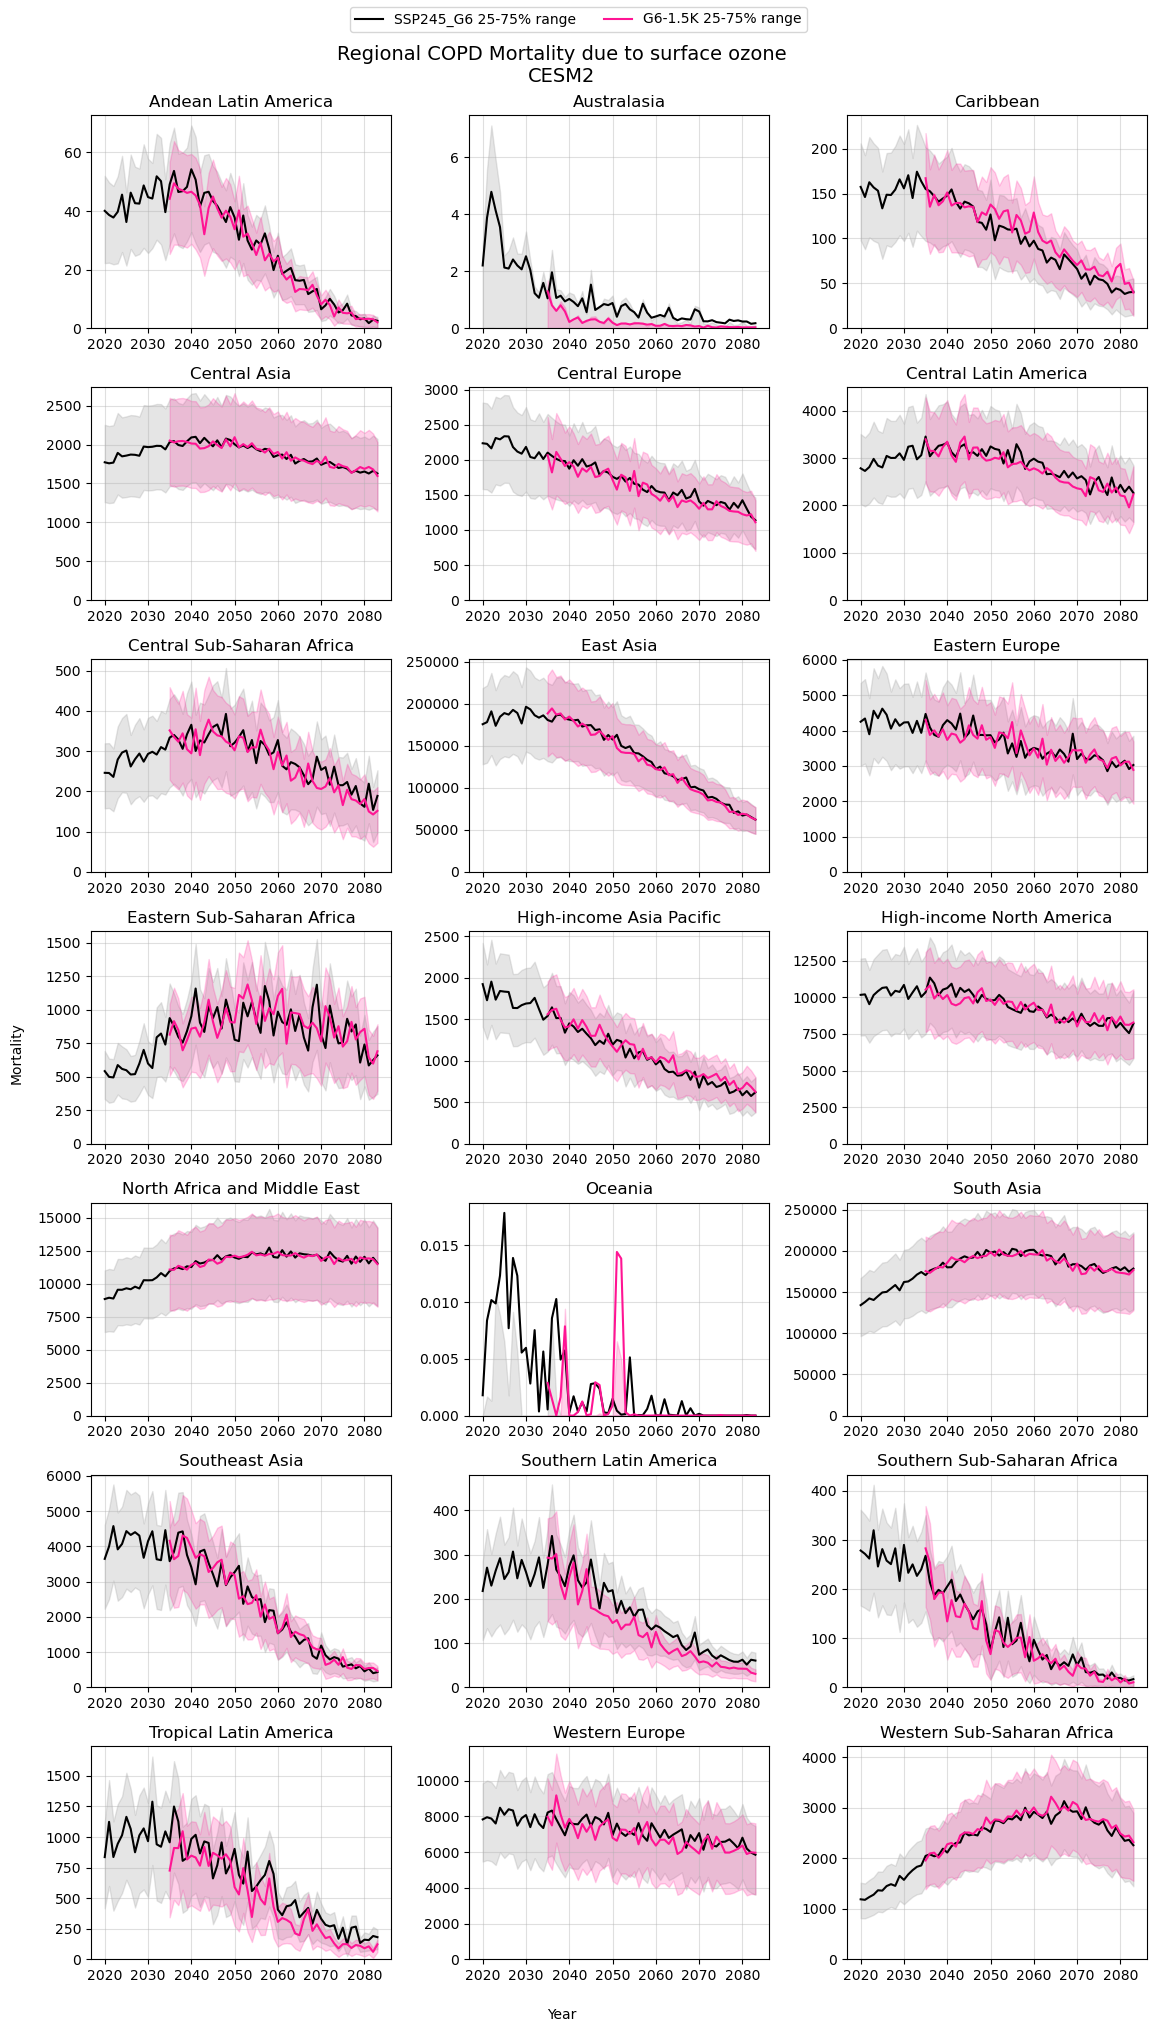

In [21]:
# Quantiles for plotting uncertainty
q1 = 0.25
q2 = 0.75
label = "25-75% range"

regions = da1["region"].values  # or a list of region names
n_regions = len(regions)

# Decide subplot grid shape (e.g. 7 rows × 3 cols)
ncols = 3
nrows = int(np.ceil(n_regions / ncols))

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols*4, nrows*3), sharex=False, sharey=False)
axes = axes.flatten()

for i, region in enumerate(regions):
    ax = axes[i]

    # Select data for this region
    da1_r = da1.sel(region=region)
    da2_r = da2.sel(region=region)

    # Compute regional means and percentiles
    da1_mean = da1_r.mean("samples")
    da1_p1 = da1_r.quantile(q1, "samples")
    da1_p2 = da1_r.quantile(q2, "samples")
    da2_mean = da2_r.mean("samples")
    da2_p1 = da2_r.quantile(q1, "samples")
    da2_p2 = da2_r.quantile(q2, "samples")

    # Plot for scenario 1
    ax.plot(da1_r["year"], da1_mean, color="k", label=f"{scenario1} {label}")
    ax.fill_between(da1_r["year"], da1_p1, da1_p2, color="gray", alpha=0.2)

    # Plot for scenario 2
    ax.plot(da2_r["year"], da2_mean, color="deeppink", label=f"{scenario2} {label}")
    ax.fill_between(da2_r["year"], da2_p1, da2_p2, color="deeppink", alpha=0.2)

    ax.set_title(region)
    ax.grid(True, alpha=0.4)
    ax.set_ylim(bottom=0)

# Remove any unused subplots
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

# Common labels and legend
fig.text(0.5, 0.04, "Year", ha="center")
fig.text(0.04, 0.5, "Mortality", va="center", rotation="vertical")

# Add one legend outside the subplots
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=2)

fig.suptitle(f"Regional COPD Mortality due to surface ozone\n{model}", fontsize=14, y=0.98)
fig.tight_layout(rect=[0.05, 0.05, 1, 0.99])
plt.show()


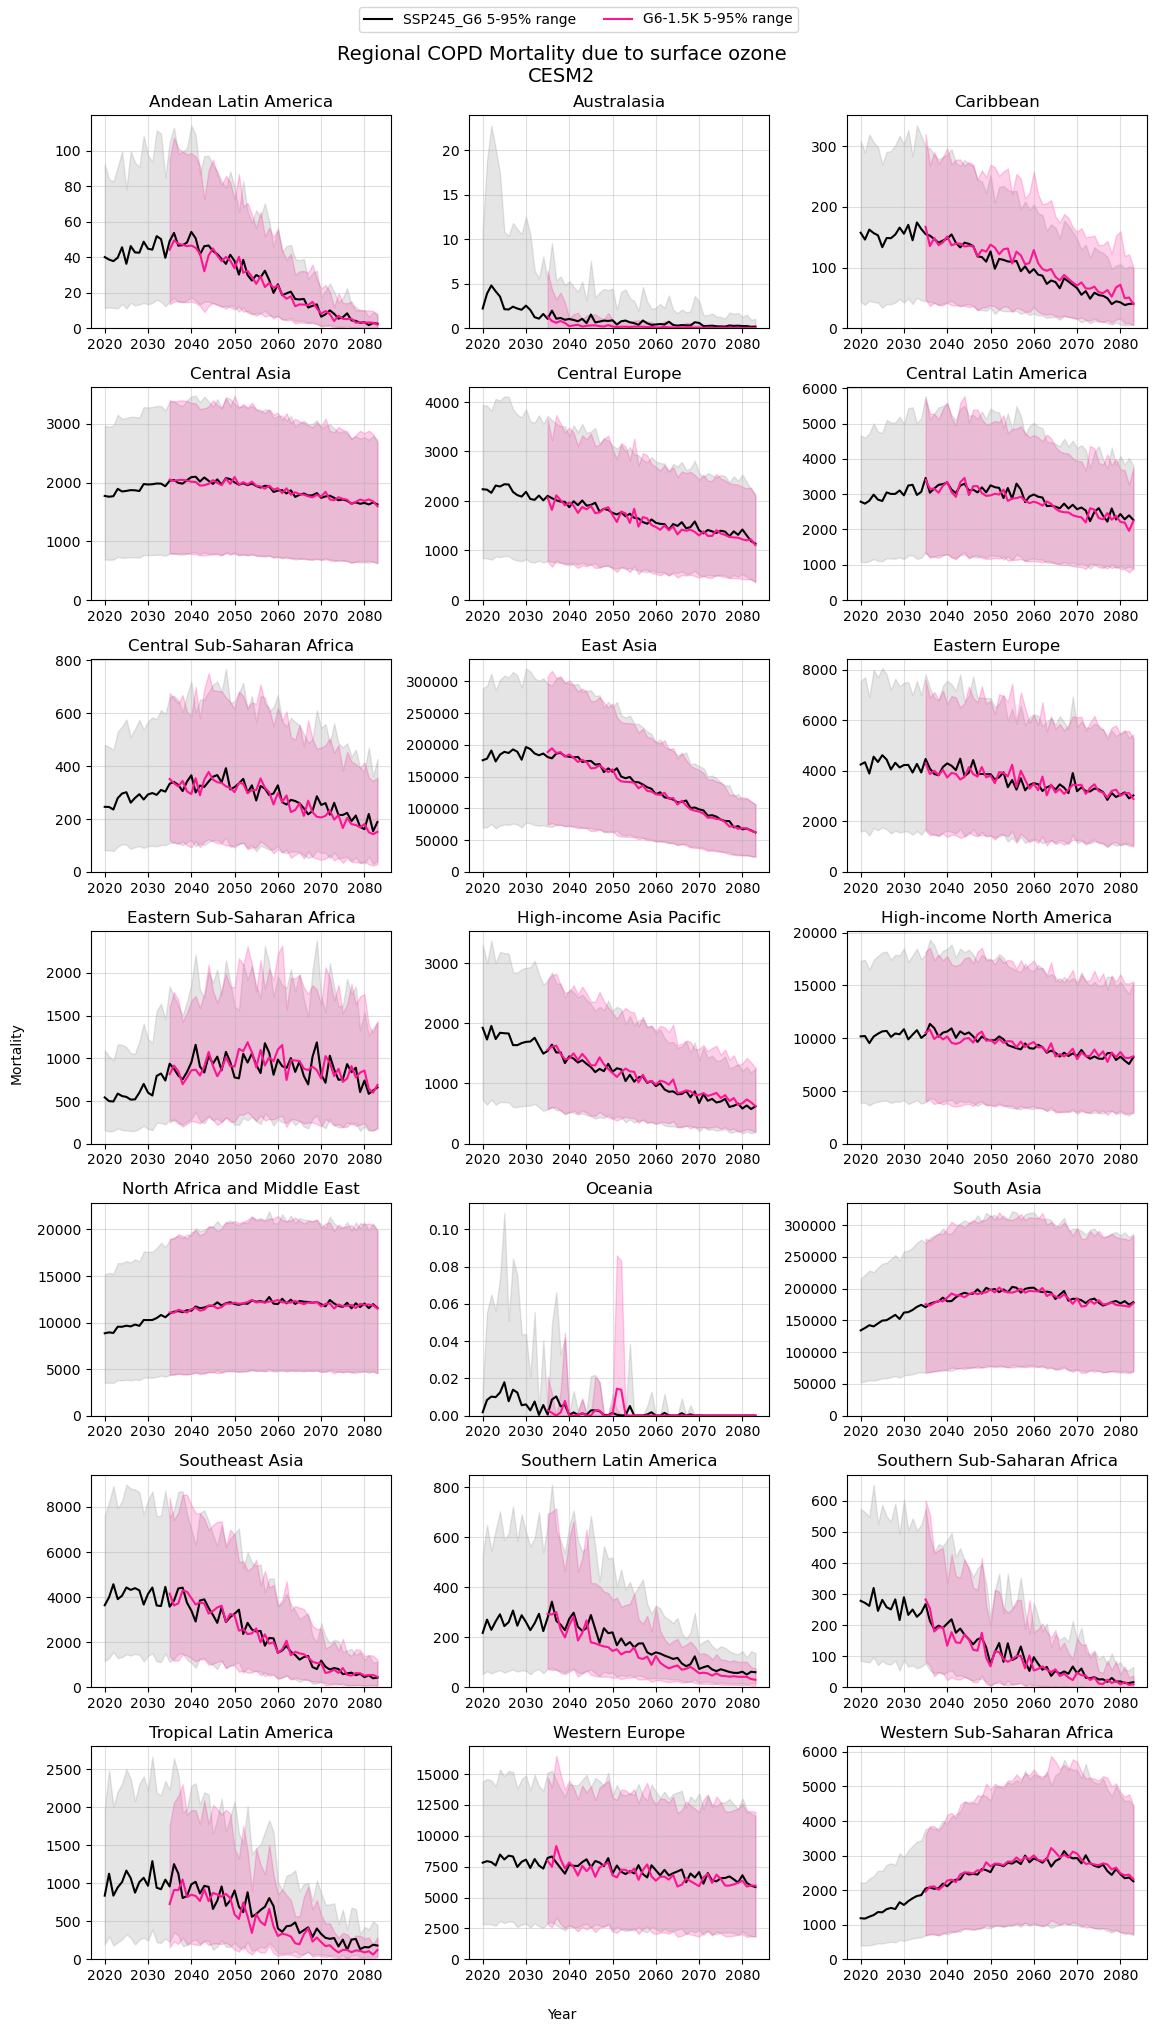

In [22]:
# Quantiles for plotting uncertainty
q1 = 0.05
q2 = 0.95
label = "5-95% range"

regions = da1["region"].values  # or a list of region names
n_regions = len(regions)

# Decide subplot grid shape (e.g. 7 rows × 3 cols)
ncols = 3
nrows = int(np.ceil(n_regions / ncols))

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols*4, nrows*3), sharex=False, sharey=False)
axes = axes.flatten()

for i, region in enumerate(regions):
    ax = axes[i]

    # Select data for this region
    da1_r = da1.sel(region=region)
    da2_r = da2.sel(region=region)

    # Compute regional means and percentiles
    da1_mean = da1_r.mean("samples")
    da1_p1 = da1_r.quantile(q1, "samples")
    da1_p2 = da1_r.quantile(q2, "samples")
    da2_mean = da2_r.mean("samples")
    da2_p1 = da2_r.quantile(q1, "samples")
    da2_p2 = da2_r.quantile(q2, "samples")

    # Plot for scenario 1
    ax.plot(da1_r["year"], da1_mean, color="k", label=f"{scenario1} {label}")
    ax.fill_between(da1_r["year"], da1_p1, da1_p2, color="gray", alpha=0.2)

    # Plot for scenario 2
    ax.plot(da2_r["year"], da2_mean, color="deeppink", label=f"{scenario2} {label}")
    ax.fill_between(da2_r["year"], da2_p1, da2_p2, color="deeppink", alpha=0.2)

    ax.set_title(region)
    ax.grid(True, alpha=0.4)
    ax.set_ylim(bottom=0)

# Remove any unused subplots
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

# Common labels and legend
fig.text(0.5, 0.04, "Year", ha="center")
fig.text(0.04, 0.5, "Mortality", va="center", rotation="vertical")

# Add one legend outside the subplots
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=2)

fig.suptitle(f"Regional COPD Mortality due to surface ozone\n{model}", fontsize=14, y=0.98)
fig.tight_layout(rect=[0.05, 0.05, 1, 0.99])
plt.show()
